[Back to Machine Learning guideline](Machine Learning.html)


## **Model Evaluation** (Fit-Goodness)

Model evaluation measures how well a trained model **generalizes to unseen data**.  
Different model types (classification, regression, clustering, etc.) require **different evaluation metrics** because their objectives differ.

### **Classification Metrics**

Classification models predict **discrete class labels**, so evaluation focuses on how well predicted labels match true labels.
- **Confusion Matrix**:
    Confusion matrix creates a N X N matrix, where N is the number of classes or categories that are to be predicted.

    |               | Predicted Positive | Predicted Negative |
    |--------------|------------------|------------------|
    | **Actual Positive** | TP (True Positive) | FN (False Negative) |
    | **Actual Negative** | FP (False Positive) | TN (True Negative) |

- **Accuracy** = $\frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$ = $\frac{\text{TP + TN}}{\text{TP + TN + FP + FN}}$

    Accuracy measures overall correctness, but not reliable for **imbalanced dataset**, for example, in a dataset with 90% class A and 10% class B, a model predicting only class A will still achieve 90% accuracy but it will fail to identify any class B instances.
  
- **Precision** = $\frac{\text{TP}}{\text{TP + FP}}$

    Precision measures how many of the positive predictions made by the model are actually correct. It's useful when the cost of false positives is high such as in medical diagnoses where predicting a disease when it’s not present can have serious consequences.


- **Recall** = $\frac{\text{TP}}{\text{TP + FN}}$

    Recall or **Sensitivity** measures how many of the actual positive cases were correctly identified by the model. It is important when missing a positive case (false negative) is more costly than false positives. In scenarios where catching all positive cases is important (like disease detection), recall is a key metric.

  
- **F1 Score** = $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision + Recall}}$

    F1 Score is the **harmonic** mean of precision and recall. It is useful when we need a balance between precision and recall as it combines both into a single number. A high F1 score means the model performs well on both metrics. Its range is [0,1]. Lower recall and higher precision gives us great accuracy but then it misses a large number of instances. More the F1 score better will be performance.

- **Geometirc mean**(G-mean) = $\sqrt{\text{Sensitivity} \times \text{Specificity}}$ = $\sqrt{\text{TPR} \times \text{TNR}}$

    The **Geometric Mean**(GM) measures how balanced a model’s performance is across classes, making it particularly useful for imbalanced datasets. It ensures that the model performs well on both positive and negative classes simultaneously, rather than favoring one over the other. Unlike accuracy, which can be misleading when one class dominates, GM will only be high if the model achieves strong performance on both sides. This is because it penalizes imbalance: if performance on either class is poor, the overall score drops significantly. It is important to note that GM is based on class-wise recall (TPR and TNR), not precision, as precision reflects the correctness of positive predictions rather than the model’s ability to correctly identify negative instances. Therefore, GM is most appropriate in scenarios where balanced classification performance is required and both types of errors matter.


- **Cross-Entropy Loss / Logarithmic Loss** (Log Loss)

    Cross-entropy loss, or log loss, measures the performance of classification models by calculating the difference between predicted probability distributions and actual labels (0 or 1). It heavily penalizes confident but incorrect predictions, with lower loss indicating better performance, making it the standard for training neural networks

    **For Binary Classification**:

    $LogLoss = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \right]$

    Where:
    - $y_i \in \{0,1\}$: true label.
    - $p_i$: predicted probability of the positive class.

    **For Multi-class Classification**

    $LogLoss = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{ik} \log(p_{ik})$

    Where:
    - $K$: number of classes  
    - $y_{ik}$: one-hot encoded true label  
    - $p_{ik}$: predicted probability for class $k$  
  
- **Receiver operating characteristic(ROC) Curve and Area Under Curve (AUC)**

    ROC and AUC are evaluation tools for **binary classification models**, especially when models output **probabilities**. They focus on evaluating a model’s ability to **distinguish between positive and negative classes**.
    - **ROC**: The ROC (Receiver Operating Characteristic) Curve is a graphical tool that evaluates a classifier’s performance by showing how the **True Positive Rate (TPR)** and **False Positive Rate (FPR)** change across different classification thresholds. It reflects the **trade-off between detecting positives and avoiding false alarms**. A curve closer to the **top-left corner** indicates better performance. The diagonal line represents **random guessing**.
    - **True Positive Rate(TPR)** = $\frac{\text{TP}}{\text{TP + FN}}$. How often the model correctly predicts the positive cases also known as Sensitivity or Recall.
    - **False Positive Rate (FPR)** = $\frac{\text{FP}}{\text{FP + TN}}$. How often the model incorrectly predicts a negative case as positive.
    - **Specificity**: it measures the proportion of actual negatives that the model correctly identifies. It is calculated as 1 - FPR.
    - **How ROC Curve is Constructed**:
        1. The model outputs predicted probabilities $p(y=1|x)$
        2. A threshold is applied to convert probabilities into class labels
        3. The threshold is varied from 1 → 0
        4. For each threshold, compute TPR, FPR.
        5. Plot points $(FPR, TPR)$
    - **AUC**: AUC(Area Under the Curve) is the **area under the ROC curve**, providing a single scalar value to summarize the model’s performance: $\text{AUC} \in [0,1]$
    - | AUC Value | Meaning |
    |----------|--------|
    | 1.0 | Perfect separation |
    | 0.9 | Excellent |
    | 0.7–0.8 | Acceptable |
    | 0.5 | Random guessing |
    | < 0.5 | Worse than random |
    - **How AUC Evaluates a Model**：AUC measures the model’s **ranking ability**, i.e., how well it separates positive and negative samples. It can be interpreted as: $\text{AUC} = P(\text{score(positive)} > \text{score(negative)})$. This means: the probability that a randomly chosen positive sample is assigned a higher score than a randomly chosen negative sample.

    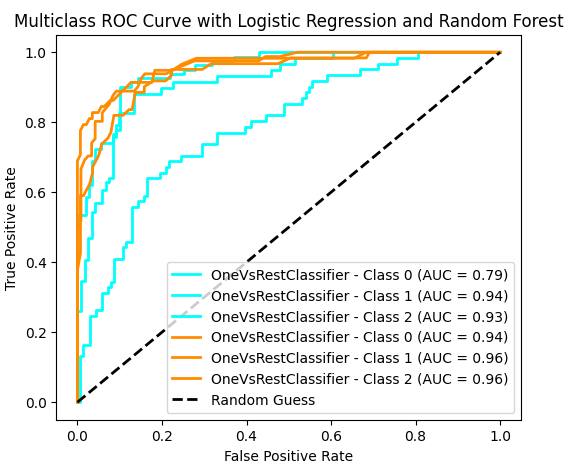

### **Regression Metrics**

Regression metrics are used to evaluate how close the predicted values $\hat{y}$ are to the true values $y$. They quantify the **prediction error** and help assess model performance from different perspectives.
    
- **Mean Absolute Error**(MAE):
    -$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$
    - MAE calculates the average of the absolute differences between the predicted and actual values. It gives a clear view of the model’s prediction accuracy but it doesn't shows whether the errors are due to over- or under-prediction(Robust to outliers). It is simple to calculate and interpret helps in making it a good starting point for model evaluation.
- **Mean Squared Error**(MSE)
    - $\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
    - MSE calculates the average of the squared differences between the predicted and actual values. Squaring the differences ensures that larger errors are penalized more heavily helps in making it sensitive to outliers. This is useful when large errors are undesirable but it can be problematic when outliers are not relevant to the model’s purpose.
- **Root Mean Squared Error**(RMSE)
    - $\text{RMSE} = \sqrt{\text{MSE}}$
    - RMSE is the square root of MSE, bringing the metric back to the original scale of the data. Like MSE, it heavily penalizes larger errors but is easier to interpret as it’s in the same units as the target variable. It’s useful when we want to know how much our predictions deviate from the actual values in terms of the same scale.
- **Root Mean Squared Logarithmic Error**(RMSLE)
    - $\text{RMSLE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( \log(\hat{y}_i + 1) - \log(y_i + 1) \right)^2 }$
    - RMSLE is useful when the target variable spans a wide range of values. Unlike RMSE, it penalizes underestimations more than overestimations helps in making it ideal for situations where the model is predicting quantities that vary greatly in scale like predicting prices or population.
- **R-squared**($R^2$)
    - $R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2} = \frac{SSR}{SST}$
    - Three types of errors: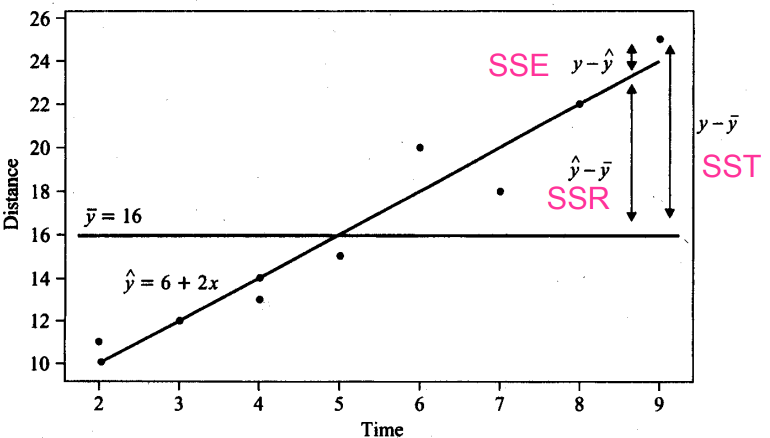
      - Sum of squared prediction errors: $SSE = \sum (y_i - \hat{y}_i)^2 = \text{actual value – predicted value}$
      - Sum of squared total errors: $SST = \sum (y_i - \bar{y})^2 = \text{actual value – mean value}$
      - Sum of squared regression errors: $SSR = \sum (\hat{y}_i - \bar{y})^2 = \text{predicted value – mean value}$
    - R2 score represents the proportion of the variance in the dependent variable that is predictable from the independent variables. An R² value close to 1 shows a model that explains most of the variance while a value close to 0 shows that the model does not explain much of the variability in the data. R² is used to assess the goodness-of-fit of regression models.

### **Clustering Metrics**
- **Silhouette Score**
- **Davies-Bouldin Index**

### **Dimensionality Reduction**
- **Reconstruction Error**
- **Explained Variance**